In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import tskit
import tszip

In [2]:
data_dir = Path("../data")
csv_file = data_dir / "recombinants.csv"
df = pd.read_csv(csv_file)
df.head(2)

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,parent_mrca_pango,parent_mrca_scorpio,parent_mrca_time,parent_mrca_date,is_rebar_recombinant,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts
0,1438470,SRR19695004,1,1,1,519,670,2,COVID-AMPLISEQ-V1,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,True,3,2,55,False,6
1,1540083,ERR9939974,1,1,1,695,958,1,COVID-ARTIC-V4.1,.,...,B.1.1.529,Omicron (Unassigned),1333.857513,2020-10-12,False,4,1,12,False,9


In [3]:
ts_file = data_dir / "sc2ts_viridian_v2.2.trees.tsz"
ts = tszip.decompress(ts_file)

In [4]:
df = df[df.net_min_supporting_loci_lft_rgt_ge_4].reset_index(drop=True)
len(df)

647

In [5]:
parent_left_is_sample = ts.nodes_flags[df.parent_left.iloc[:].to_numpy()] == tskit.NODE_IS_SAMPLE
parent_right_is_sample = ts.nodes_flags[df.parent_right.iloc[:].to_numpy()] == tskit.NODE_IS_SAMPLE
df["parent_left_is_sample"] = parent_left_is_sample
df["parent_right_is_sample"] = parent_right_is_sample
df

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,parent_mrca_time,parent_mrca_date,is_rebar_recombinant,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts,parent_left_is_sample,parent_right_is_sample
0,1872434,ERR12554229,2,1,1,2335,3431,1,COVID-ARTIC-V3,.,...,961.384849,2021-10-19,True,13,4,75,True,5,True,False
1,1358369,ERR9380041,1,1,1,2833,3542,0,COVID-ARTIC-V4.1,4.1alt,...,1333.857513,2020-10-12,True,3,5,46,True,5,False,False
2,1890014,ERR13322922,2,1,1,3432,3565,2,COVID-ARTIC-V5.0-5.3.2_400,.,...,961.384849,2021-10-19,True,10,4,72,True,6,True,False
3,1793239,ERR11148908,5,1,1,3858,3927,3,COVID-ARTIC-V4.1,.,...,961.384849,2021-10-19,True,12,5,38,True,7,True,False
4,857687,ERR7480952,2,2,1,3402,4100,2,COVID-ARTIC-V4.1,4,...,1268.244029,2020-12-16,False,2,5,15,True,7,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642,1602821,SRR21222419,1,1,1,27439,28681,1,COVID-ARTIC-V4.1,.,...,828.000001,2022-03-01,False,5,9,4,True,5,True,False
643,366701,SRR17445276,5,1,1,28096,28697,1,COVID-ARTIC-V3,.,...,1359.893278,2020-09-16,False,1,19,4,True,7,False,False
644,112685,ERR5220706,1,1,1,28718,28881,0,COVID-ARTIC-V3,.,...,1591.661216,2020-01-28,False,3,40,4,True,6,True,False
645,1680627,SRR22037361,2,2,1,27890,29253,0,COVID-ARTIC-V4.1,.,...,1333.857513,2020-10-12,True,3,19,5,True,5,True,False


In [6]:
sub_df = df[df.parent_left_is_sample & df.parent_right_is_sample].reset_index(drop=True)
sub_df

,recombinant,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,...,parent_mrca_time,parent_mrca_date,is_rebar_recombinant,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4,k1000_muts,parent_left_is_sample,parent_right_is_sample
0,857687,ERR7480952,2,2,1,3402,4100,2,COVID-ARTIC-V4.1,4,...,1268.244029,2020-12-16,False,2,5,15,True,7,True,True
1,978075,SRR20186337,2,1,1,3123,4181,3,COVID-AMPLISEQ-V1,.,...,1454.533651,2020-06-13,False,2,6,39,True,9,True,True
2,1280575,ERR9002000,1,1,1,2833,4184,0,COVID-ARTIC-V4.1,4.1alt,...,1333.857513,2020-10-12,True,3,4,47,True,4,True,True
3,1352577,ERR9381847,1,1,1,4010,4184,3,COVID-ARTIC-V4.1,4.1alt,...,1333.857513,2020-10-12,True,4,5,47,True,8,True,True
4,1169203,ERR8495032,5,1,1,4185,4321,0,COVID-ARTIC-V4.1,4.1alt,...,1333.857513,2020-10-12,True,3,5,44,True,5,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,445228,ERR6574429,1,1,1,26417,28291,1,COVID-ARTIC-V3,3,...,1268.244029,2020-12-16,False,3,10,4,True,5,True,True
220,1704281,SRR22484659,2,1,1,27439,28312,1,COVID-ARTIC-V4.1,.,...,828.000001,2022-03-01,False,10,13,4,True,5,True,True
221,1645177,SRR21636269,1,1,1,27439,28330,0,COVID-ARTIC-V4.1,.,...,828.000001,2022-03-01,False,4,10,4,True,5,True,True
222,1855611,SRR27380455,1,1,1,27817,28447,3,COVID-ARTIC-V5.0-5.3.2_400,.,...,434.000000,2023-03-30,True,8,14,4,True,7,True,True


In [7]:
md_file = data_dir / "run_metadata.v05.tsv.gz"
vir_df = pd.read_csv(md_file, sep="\t")
vir_df.head(2)

/var/folders/4h/9ylb643n37d8jc7srjm7qzk00000gr/T/ipykernel_3854/3922344101.py:2: DtypeWarning: Columns (18,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  vir_df = pd.read_csv(md_file, sep="\t")


,In_may_2024_preprint,Study,Sample,Experiment,Run,Run_count,Platform,Country,Region,Collection_date,...,Genbank_N,Viridian_pangolin,Viridian_scorpio,Genbank_pangolin,Genbank_scorpio,Genbank_tree_name,Viridian_cons_len,Viridian_cons_het,Viridian_pangolin_1.29,Viridian_scorpio_1.29
0,T,PRJEB47121,SAMEA9781395,ERX6172603,ERR6546375,1,ILLUMINA,Estonia,none,2021-08-02,...,.,AY.100,Delta (B.1.617.2-like),.,.,.,29810,0,AY.100,Delta (B.1.617.2-like)
1,T,PRJEB47121,SAMEA9781396,ERX6172604,ERR6546376,1,ILLUMINA,Estonia,none,2021-08-02,...,.,AY.122,Delta (B.1.617.2-like),.,.,.,29807,3,AY.122,Delta (B.1.617.2-like)


In [8]:
metadata_by_run = (
    vir_df[["Run", "Country", "Region"]]
    .drop_duplicates("Run", keep="first")
    .set_index("Run")
)
metadata_by_run.loc[metadata_by_run["Country"] == "United Kingdom", "Region"] = "UK"

parent_ids = pd.unique(sub_df[["parent_left", "parent_right"]].to_numpy().ravel())
accession_by_node = {
    int(node_id): ts.node(id_=int(node_id)).metadata["sample_id"]
    for node_id in parent_ids
}


def get_parent_metadata(node_ids):
    accessions = node_ids.map(accession_by_node).tolist()
    metadata = metadata_by_run.loc[accessions]
    return accessions, metadata["Country"].tolist(), metadata["Region"].tolist()


parent_left_accessions, parent_left_countries, parent_left_regions = get_parent_metadata(
    sub_df["parent_left"]
)
parent_right_accessions, parent_right_countries, parent_right_regions = get_parent_metadata(
    sub_df["parent_right"]
)

In [9]:
sub_df["abs_parent_time_diff"] = [round(x, 1) for x in abs(sub_df["parent_left_time"] - sub_df["parent_right_time"])]

sub_df["parent_left_accession"] = parent_left_accessions
sub_df["parent_left_country"] = parent_left_countries
sub_df["parent_left_region"] = parent_left_regions

sub_df["parent_right_accession"] = parent_right_accessions
sub_df["parent_right_country"] = parent_right_countries
sub_df["parent_right_region"] = parent_right_regions

In [10]:
sub_df["parent_left_country"].unique()

array(['United Kingdom', 'USA', 'South Africa', 'Denmark', 'Slovakia',
       'India', 'Austria', 'Portugal', 'Bangladesh', 'Argentina',
       'Zimbabwe', 'Germany', 'Netherlands', 'Japan'], dtype=object)

In [11]:
sub_df["parent_right_country"].unique()

array(['United Kingdom', 'USA', 'Denmark', 'Estonia', 'Germany', 'India',
       'Portugal', 'Slovakia', 'Austria', 'South Africa', 'Argentina',
       'Spain'], dtype=object)

In [12]:
sub_df["abs_parent_time_diff"].describe()

count    224.000000
mean      49.272321
std       63.283134
min        0.000000
25%       10.000000
50%       25.000000
75%       64.000000
max      468.000000
Name: abs_parent_time_diff, dtype: float64

In [13]:
print(f"Same-country: {sum(sub_df["parent_left_country"] == sub_df["parent_right_country"])}")
print(f"    USA-USA: {sum((sub_df["parent_left_country"] == "USA") & (sub_df["parent_right_country"] == "USA"))}")
print(f"    UK-UK: {sum((sub_df["parent_left_country"] == "United Kingdom") & (sub_df["parent_right_country"] == "United Kingdom"))}")
print(f"    DK-DK: {sum((sub_df["parent_left_country"] == "Denmark") & (sub_df["parent_right_country"] == "Denmark"))}")
print(f"Diff-country: {sum(sub_df["parent_left_country"] != sub_df["parent_right_country"])}")
print(f"Total: {len(sub_df)}")

Same-country: 134
    USA-USA: 70
    UK-UK: 52
    DK-DK: 8
Diff-country: 90
Total: 224


In [14]:
import matplotlib.pyplot as plt

def create_histogram(ax):
    ax.hist(
        sub_df["abs_parent_time_diff"],
        bins=50,
        color="#4477AA",
        edgecolor="white",
        linewidth=0.6,
    )

    ax.axvline(
        sub_df["abs_parent_time_diff"].median(),
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Median",
    )
    ax.legend(frameon=False)

    ax.set(
        xlabel="Absolute difference in parent times",
        ylabel="Number of recombination events",
    )
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.01)

    return ax


def create_heatmap(ax, cofreq):
    fig = ax.figure
    im = ax.imshow(cofreq, cmap="viridis", aspect="equal")

    fig.colorbar(im, ax=ax, label="Number of recombination events")

    for (i, j), value in np.ndenumerate(cofreq):
        ax.text(
            j, i, f"{value:.2g}",
            ha="center",
            va="center",
            color="white" if im.norm(value) < 0.5 else "black",
        )

    ax.set_xticks(
        np.arange(cofreq.shape[1]),
        labels=getattr(cofreq, "columns", np.arange(cofreq.shape[1])),
    )
    ax.set_yticks(
        np.arange(cofreq.shape[0]),
        labels=getattr(cofreq, "index", np.arange(cofreq.shape[0])),
    )

    ax.set_ylabel("Country of left parent")
    ax.set_xlabel("Country of right parent")

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    return ax

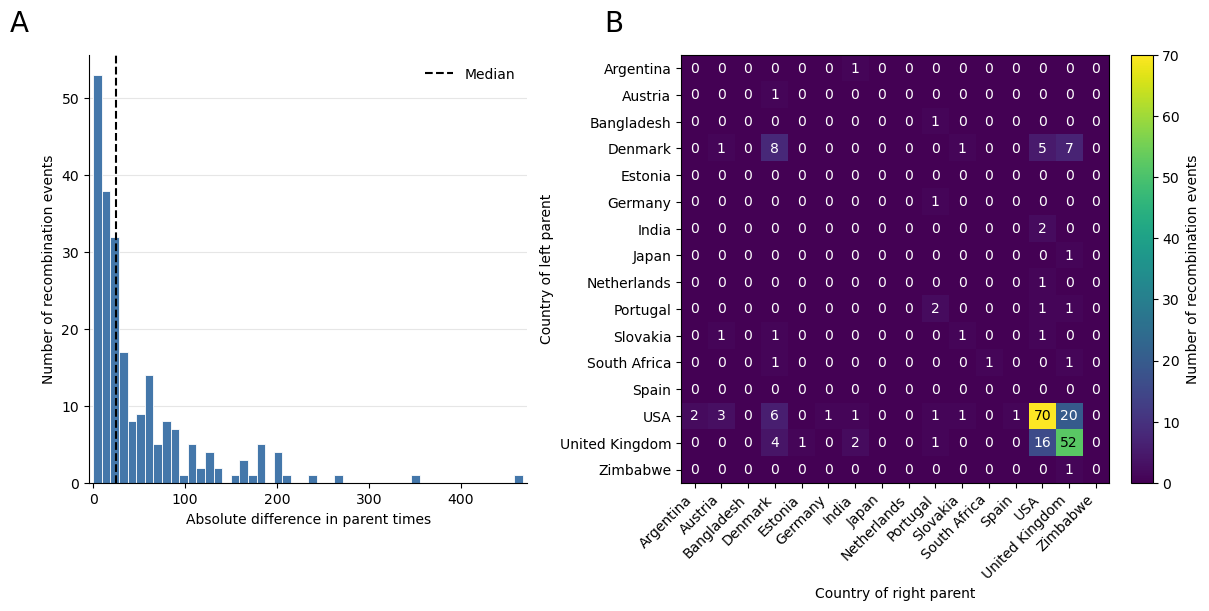

In [15]:
labels = pd.Index(sub_df["parent_left_country"]).union(pd.Index(sub_df["parent_right_country"])).unique()
cofreq = pd.crosstab(sub_df["parent_left_country"], sub_df["parent_right_country"]).reindex(
    index=labels,
    columns=labels,
    fill_value=0,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

create_histogram(axes[0])
create_heatmap(axes[1], cofreq)

for ax, label in zip(axes, ("A", "B")):
    ax.text(
        -0.18, 1.04, label,
        transform=ax.transAxes,
        fontsize=20,
        fontweight="normal",
        ha="left",
        va="bottom",
    )

figures_dir = Path("../figures")

fig.savefig(figures_dir / "recombinant_parent_proximity.pdf", bbox_inches="tight")
plt.show()